In [1]:
%autosave 60
%pip install --quiet -r requirements.txt

Autosaving every 60 seconds
Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
import os
import numpy as np
import random
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import defaultdict
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import fit_3D, fit_3D_gan
from utils.loss_functions import recon_loss
from models.alzheiminator_3d import ResidualUNet3D, Discriminator3D, Generator3D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Flush cuda memory

In [3]:
torch.cuda.empty_cache()

Common Variables

In [4]:
model_epochs = 1000
print_every = 100
save_every = 250

In [5]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


## 3D U-Net

In [6]:
output_dir = "out/unet_models"
model_path = f"{output_dir}/3d_unet_model.pt"
model = ResidualUNet3D(in_ch=1, base=32).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

In [7]:
# Load existing model if it exists
if os.path.isfile(model_path):
    model.load_state_dict(torch.load(model_path))
else:
    os.makedirs(output_dir, exist_ok=True)
    
print(len(training_pairs), "training pairs")

562 training pairs


In [8]:
model, snapshots = fit_3D(
    model=model,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    criterion=recon_loss,
    epochs=model_epochs,
    print_every=print_every,
    save_every=save_every
)

[Iter 0] total: 0.717474 (custom criterion) + TV
Saved snapshot at iter 0 (mid-axial slice)
[Iter 100] total: 0.277368 (custom criterion) + TV
[Iter 200] total: 0.201241 (custom criterion) + TV
Saved snapshot at iter 250 (mid-axial slice)
[Iter 300] total: 0.199231 (custom criterion) + TV
[Iter 400] total: 0.203608 (custom criterion) + TV
[Iter 500] total: 0.189350 (custom criterion) + TV
Saved snapshot at iter 500 (mid-axial slice)
[Iter 600] total: 0.203258 (custom criterion) + TV
[Iter 700] total: 0.198014 (custom criterion) + TV
Saved snapshot at iter 750 (mid-axial slice)
[Iter 800] total: 0.190693 (custom criterion) + TV
[Iter 900] total: 0.196572 (custom criterion) + TV
Saved snapshot at iter 999 (mid-axial slice)


Displaying snapshot from pair 0, loss: 0.7175


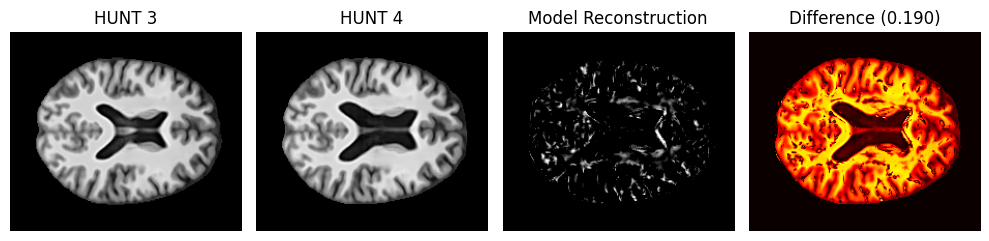

Displaying snapshot from pair 250, loss: 0.2288


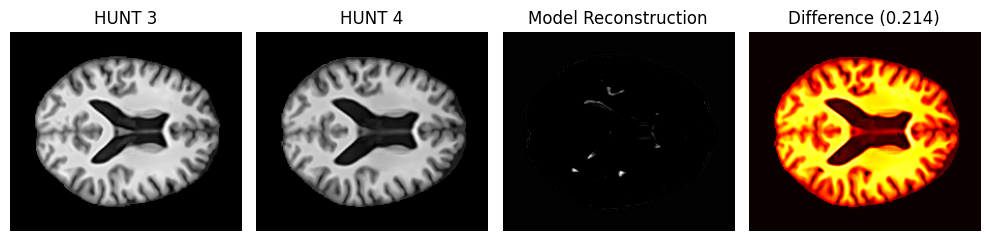

Displaying snapshot from pair 500, loss: 0.1894


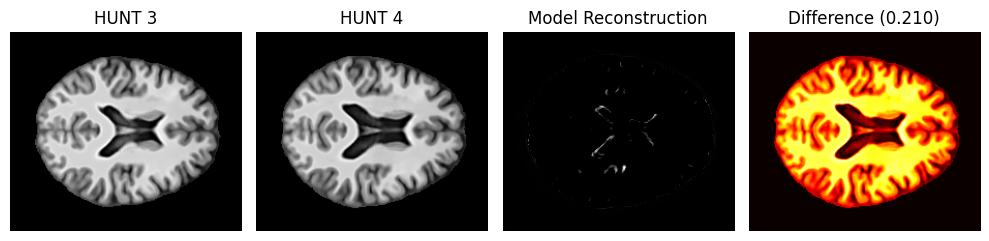

Displaying snapshot from pair 750, loss: 0.1950


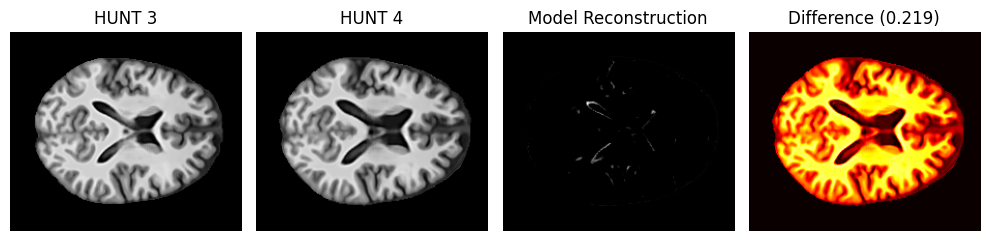

Displaying snapshot from pair 999, loss: 0.1814


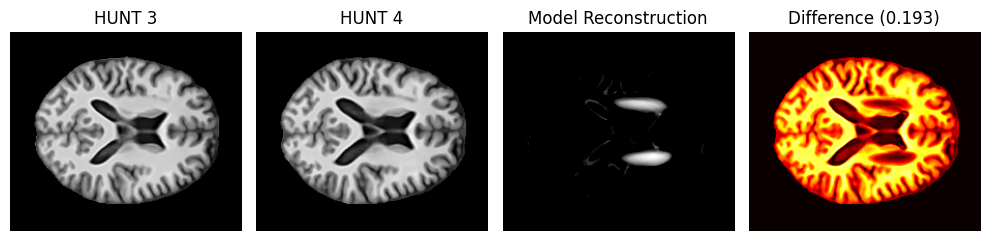

In [9]:
for snapshot in snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}, loss: {snapshot['loss']:.4f}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [10]:
# Save the final model to /out directory
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to out/unet_models/3d_unet_model.pt


## MP-GAN

## Compare U-Net and MP-GAN

From Earlier we have the models
|                           | **VAE**                                          | **UNet**                                           |
| ------------------------- | ------------------------------------------------------ | -------------------------------------------------------- |
| **Whole dataset**         | `vae`               | `unet`               |
| **Slice-specific models** | `slice_vae_models`  | `slice_unet_models`  |


### See Loss statistics

In [11]:
# Load saved Losses
vae_loss = np.loadtxt("out/vae_2d_loss_history.csv", delimiter=",")
unet_loss = np.loadtxt("out/unet_2d_loss_history.csv", delimiter=",")
slice_vae_loss = np.loadtxt("out/slice_vae_2d_loss_history.csv", delimiter=",")
slice_unet_loss = np.loadtxt("out/slice_unet_2d_loss_history.csv", delimiter=",")

FileNotFoundError: out/vae_2d_loss_history.csv not found.

In [ ]:
print(vae_loss[-5:])

[0.18104916 0.16622464 0.16482832 0.15288504 0.17523017]


In [ ]:
print(slice_vae_loss[-5:])

[0.18566476 0.18328829 0.18322796 0.19189601 0.18944197]


In [ ]:
print(unet_loss[-5:])

[0.04679015 0.04802403 0.06467541 0.04927621 0.05863217]


In [ ]:
print(slice_unet_loss[-5:])

[0.09535782 0.09930484 0.09348065 0.09768255 0.08669263]


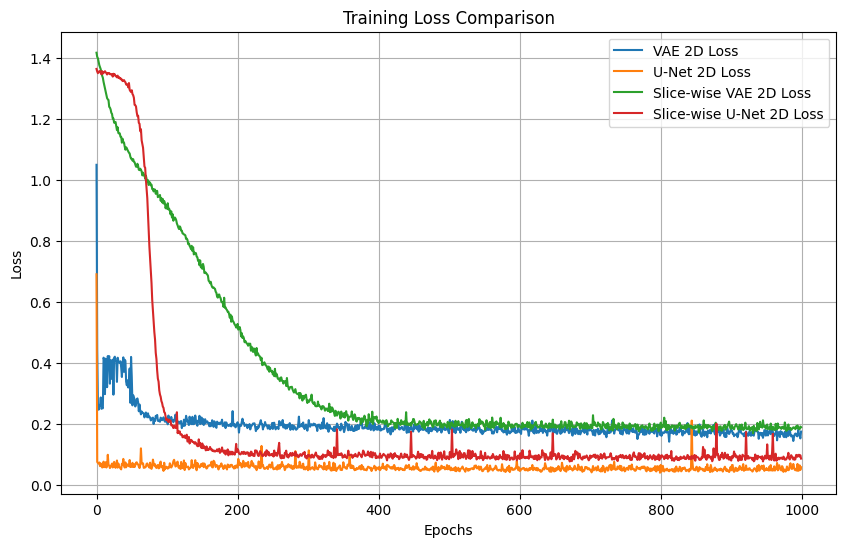

In [ ]:
# Plot all losses together
series = [vae_loss, unet_loss, slice_vae_loss, slice_unet_loss]
series = [np.array(s, dtype=float) for s in series if s is not None and len(s) > 0]

plt.figure(figsize=(10,6))
plt.plot(vae_loss, label="VAE 2D Loss")
plt.plot(unet_loss, label="U-Net 2D Loss")
plt.plot(slice_vae_loss, label="Slice-wise VAE 2D Loss")
plt.plot(slice_unet_loss, label="Slice-wise U-Net 2D Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.savefig("out/loss_comparison.png")
plt.show()

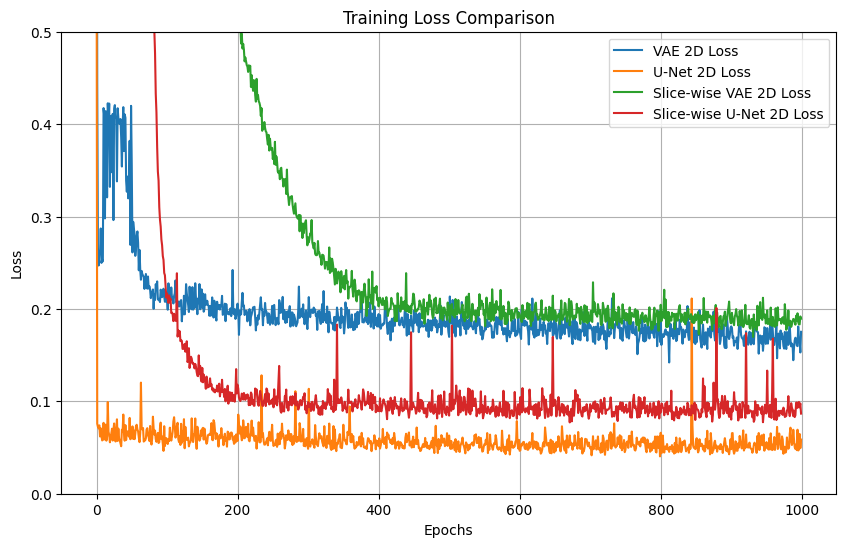

In [ ]:
series = [vae_loss, unet_loss, slice_vae_loss, slice_unet_loss]
series = [np.array(s, dtype=float) for s in series if s is not None and len(s) > 0]

plt.figure(figsize=(10,6))
plt.plot(vae_loss, label="VAE 2D Loss")
plt.plot(unet_loss, label="U-Net 2D Loss")
plt.plot(slice_vae_loss, label="Slice-wise VAE 2D Loss")
plt.plot(slice_unet_loss, label="Slice-wise U-Net 2D Loss")
plt.ylim(0, 0.5)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.savefig("out/loss_comparison_cropped.png")
plt.show()

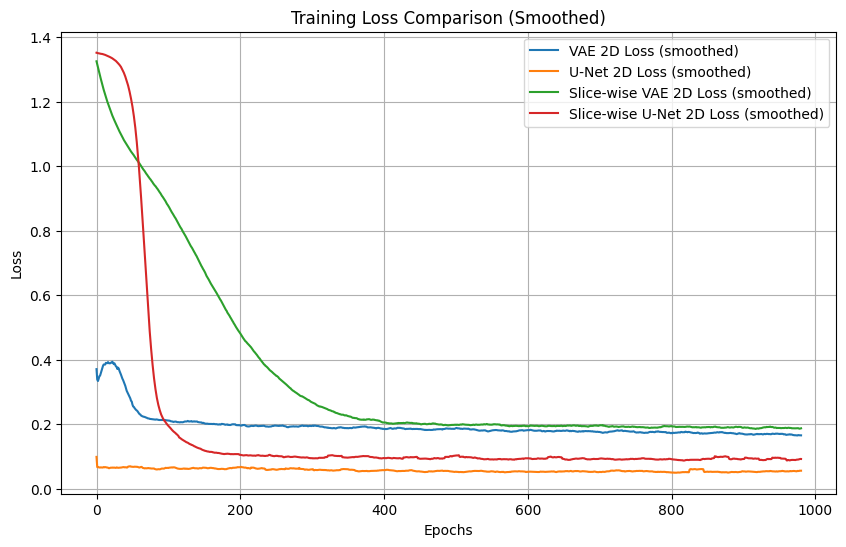

In [ ]:
def smooth(y, window=20):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

series = [vae_loss, unet_loss, slice_vae_loss, slice_unet_loss]
series = [np.array(s, dtype=float) for s in series if s is not None and len(s) > 0]

plt.figure(figsize=(10,6))
plt.plot(smooth(vae_loss), label="VAE 2D Loss (smoothed)")
plt.plot(smooth(unet_loss), label="U-Net 2D Loss (smoothed)")
plt.plot(smooth(slice_vae_loss), label="Slice-wise VAE 2D Loss (smoothed)")
plt.plot(smooth(slice_unet_loss), label="Slice-wise U-Net 2D Loss (smoothed)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Smoothed)")
plt.legend()
plt.grid()
plt.savefig("out/loss_comparison_smoothed.png")
plt.show()


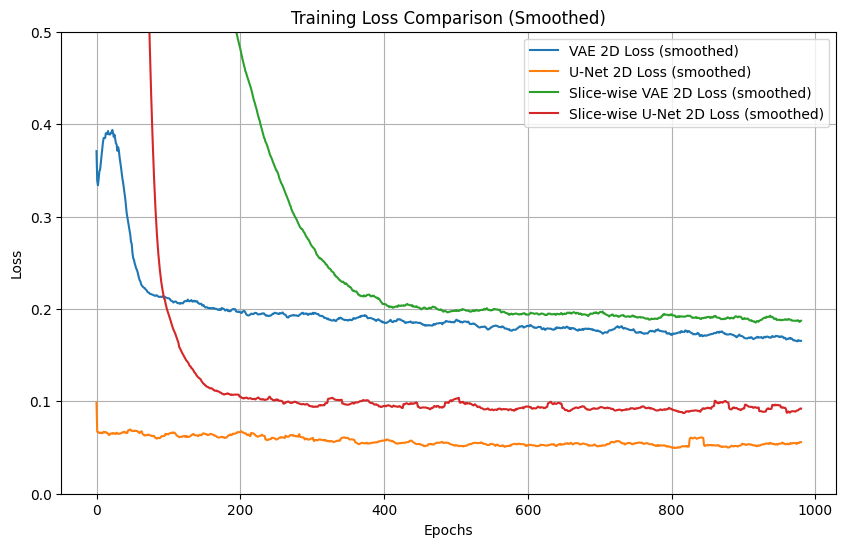

In [ ]:
def smooth(y, window=20):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

series = [vae_loss, unet_loss, slice_vae_loss, slice_unet_loss]
series = [np.array(s, dtype=float) for s in series if s is not None and len(s) > 0]

plt.figure(figsize=(10,6))
plt.plot(smooth(vae_loss), label="VAE 2D Loss (smoothed)")
plt.plot(smooth(unet_loss), label="U-Net 2D Loss (smoothed)")
plt.plot(smooth(slice_vae_loss), label="Slice-wise VAE 2D Loss (smoothed)")
plt.plot(smooth(slice_unet_loss), label="Slice-wise U-Net 2D Loss (smoothed)")
plt.ylim(0, 0.5)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Smoothed)")
plt.legend()
plt.grid()
plt.savefig("out/loss_comparison_smoothed_cropped.png")
plt.show()


### Import and Generate Slices

#### Setup

We load all models and data again so this can be run seperatly from main training loop

In [ ]:
test_images = 4

# Same split as during training 
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


We load the same models (So we don't have to run everything over before this)

In [ ]:
vae = VAE(latent_dim=64).to(device)
vae.load_state_dict(torch.load("out/vae_models/2d_vae_model.pt"))

unet = UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)
unet.load_state_dict(torch.load("out/unet_models/2d_unet_model.pt"))

slice_vae = [VAE(latent_dim=64).to(device) for _ in range(193)]
slice_unet = [UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device) for _ in range(193)]
for i in range(193):
    slice_vae[i].load_state_dict(torch.load(f"out/vae_models/multi/2d_vae_model_slice_{i}.pt"))
    slice_unet[i].load_state_dict(torch.load(f"out/unet_models/multi/2d_unet_model_slice_{i}.pt"))

#### Import and predict 5 random slices

Displaying results for test image 51, slice 147


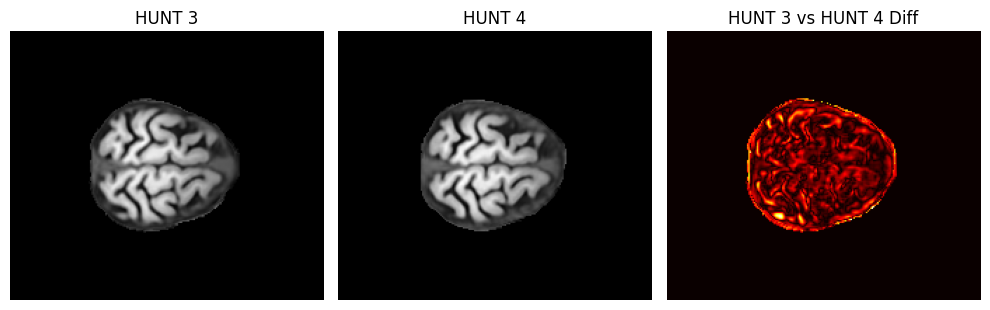

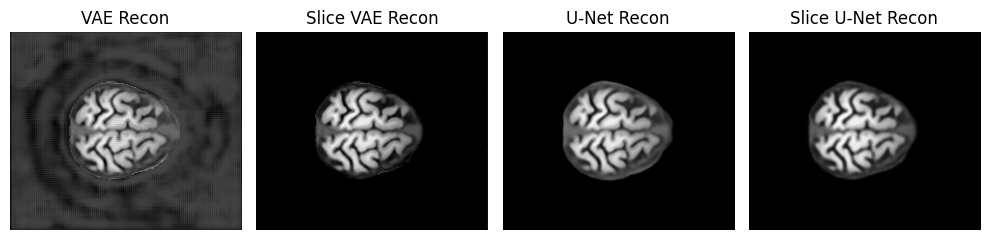

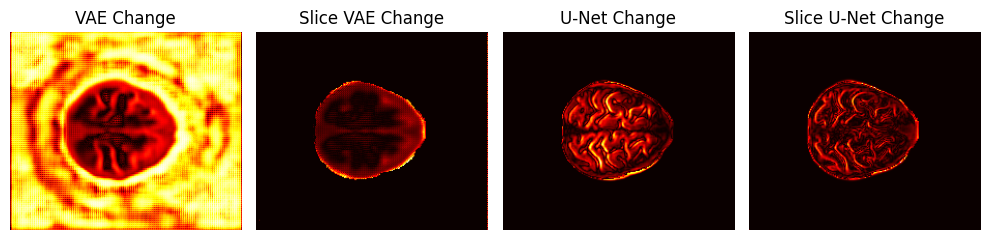

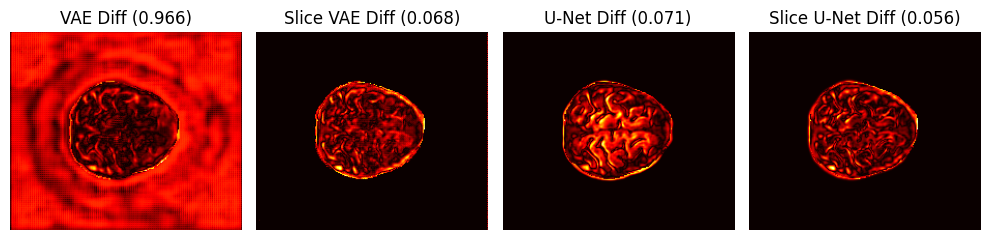

Displaying results for test image 64, slice 148


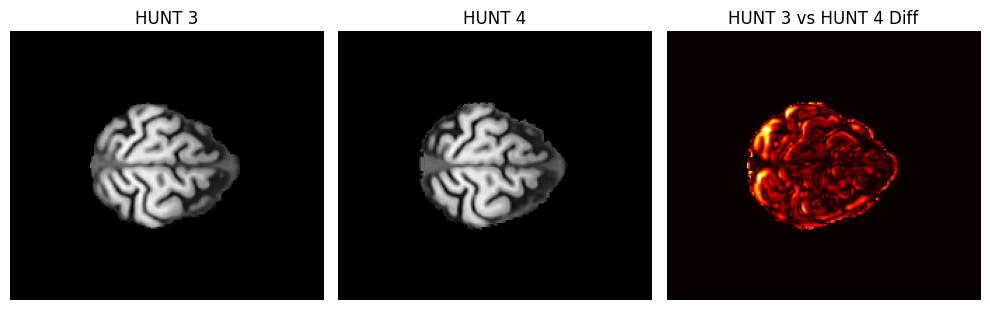

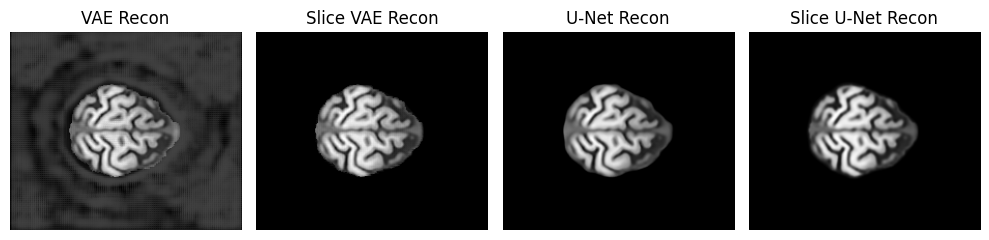

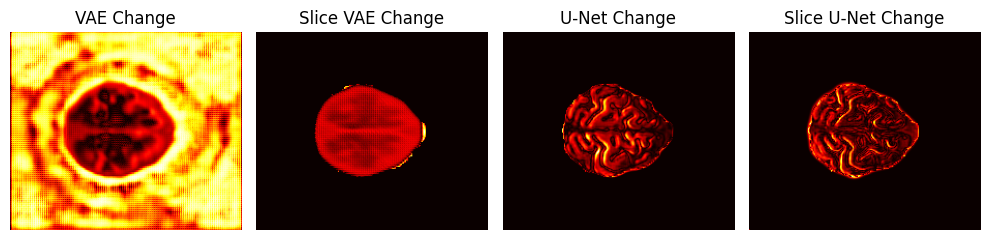

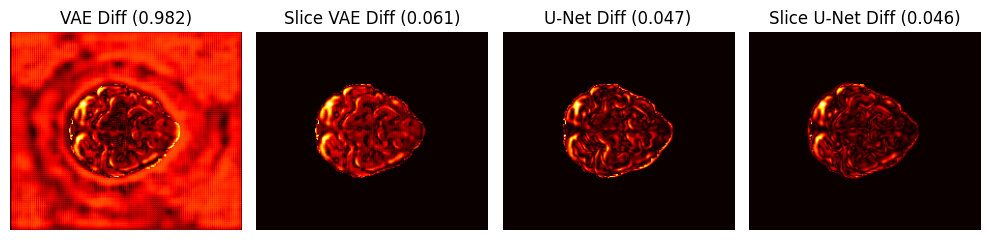

Displaying results for test image 86, slice 138


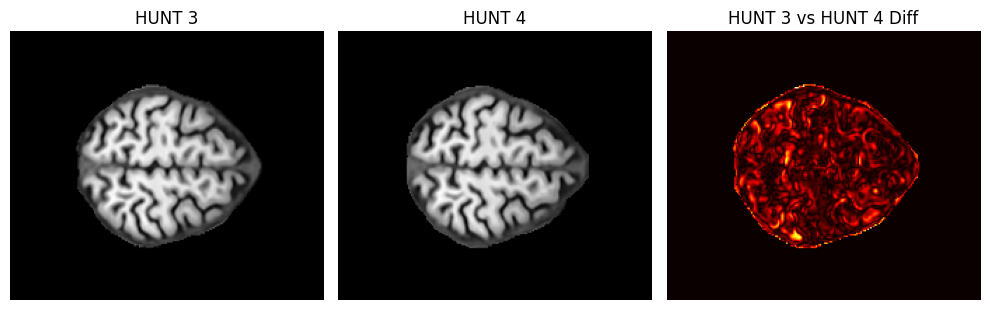

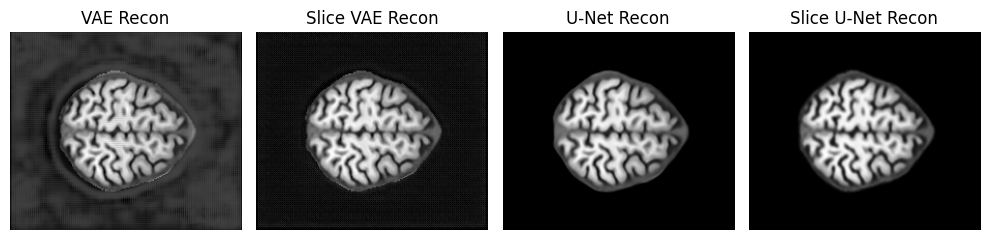

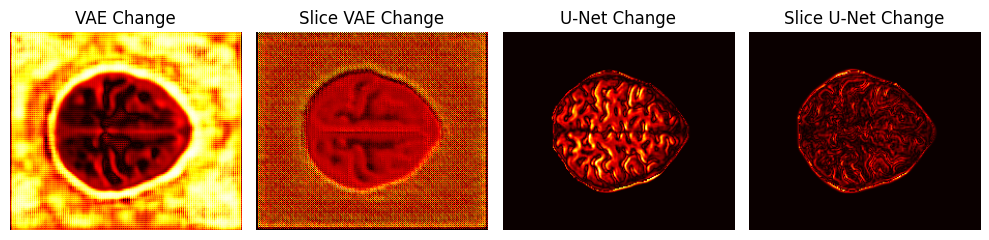

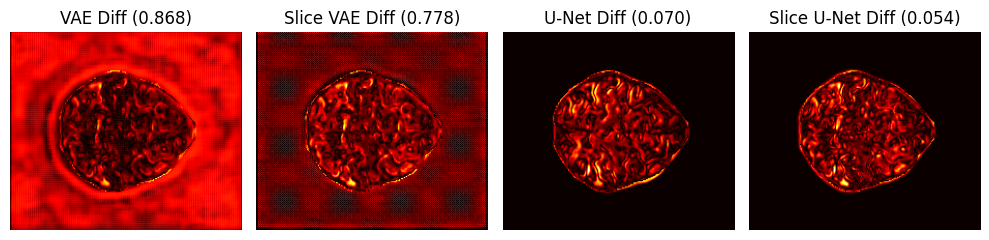

Displaying results for test image 60, slice 141


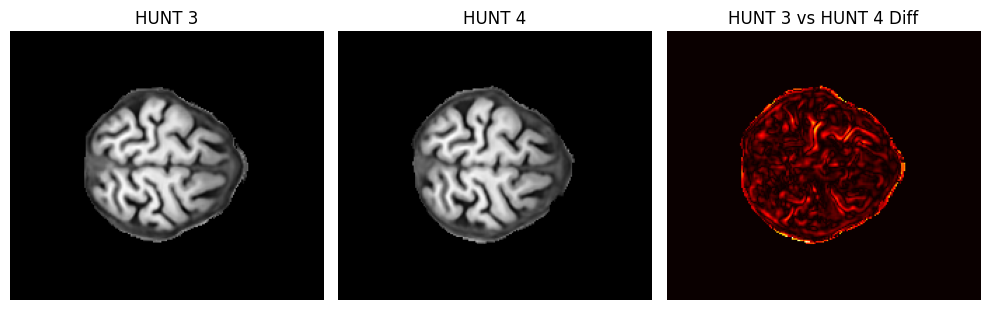

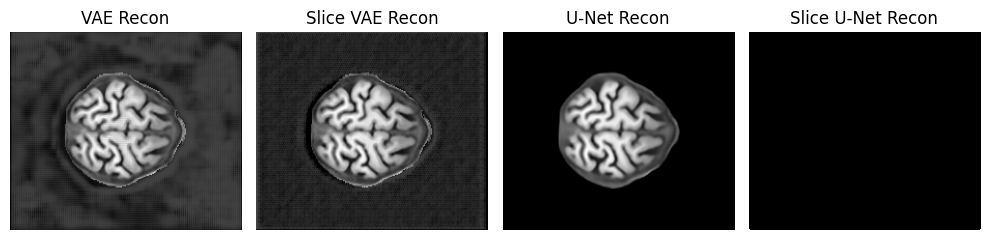

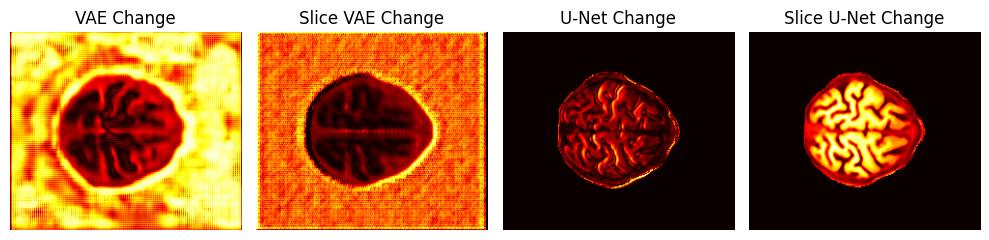

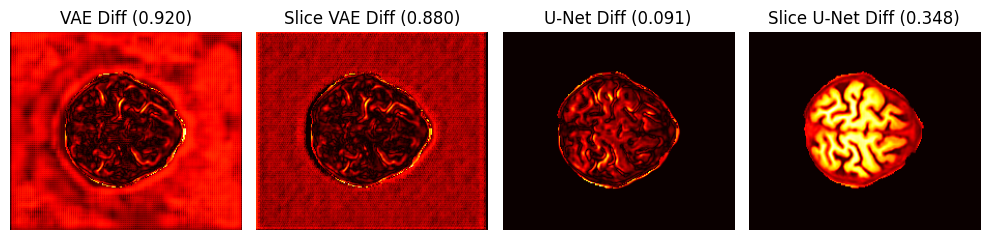

In [ ]:
for i in range(test_images):
    padding = 20
    slice = random.randint(padding, 192 - padding)
    candidate = random.randint(0, len(test_pairs)-1)
    x_num, y_num = data_loader.get_slice(data_path=test_pairs[candidate][0], crop_size=(192, 224), index=slice), data_loader.get_slice(data_path=test_pairs[candidate][1], crop_size=(192, 224), index=slice)
    x = data_loader.to_torch_img(x_num, device)
    y = data_loader.to_torch_img(y_num, device)

    vae_recon_tensor, _, _ = vae(x)
    unet_recon_tensor, _, _ = unet(x)

    slice_vae_recon_tensor, _, _ = slice_vae[slice](x)
    slice_unet_recon_tensor, _, _ = slice_unet[slice](x)

    # Convert Tensor reconstructions to numpy for display
    vae_recon = data_loader.to_numpy_img(vae_recon_tensor)
    unet_recon = data_loader.to_numpy_img(unet_recon_tensor)
    slice_vae_recon = data_loader.to_numpy_img(slice_vae_recon_tensor)
    slice_unet_recon = data_loader.to_numpy_img(slice_unet_recon_tensor)

    # How much the models change from the input
    vae_change = np.abs(vae_recon - x_num)
    unet_change = np.abs(unet_recon - x_num)
    slice_vae_change = np.abs(slice_vae_recon - x_num)
    slice_unet_change = np.abs(slice_unet_recon - x_num)

    # Difference between reconstructions and ground truth
    vae_diff = np.abs(vae_recon - y_num)
    unet_diff = np.abs(unet_recon - y_num)
    slice_vae_diff = np.abs(slice_vae_recon - y_num)
    slice_unet_diff = np.abs(slice_unet_recon - y_num)
    hunt_diff = np.abs(x_num - y_num)

    # Prediction errors (SSIM+L1)
    vae_pred_error = ssim_L1_2d_loss(vae_recon_tensor, y).item()
    unet_pred_error = ssim_L1_2d_loss(unet_recon_tensor, y).item()
    slice_vae_pred_error = ssim_L1_2d_loss(slice_vae_recon_tensor, y).item()
    slice_unet_pred_error = ssim_L1_2d_loss(slice_unet_recon_tensor, y).item()

    print(f"Displaying results for test image {candidate}, slice {slice}")

    # Hunt 3, Hunt 4, and the difference between them
    data_loader.display_slices(
        slices=[x_num, y_num, hunt_diff],
        slice_labels=["HUNT 3", "HUNT 4", "HUNT 3 vs HUNT 4 Diff"],
        slice_colors=["gray", "gray", "hot"]
    )

    # The four models’ outputs
    data_loader.display_slices(
        slices=[vae_recon, slice_vae_recon, unet_recon, slice_unet_recon],
        slice_labels=["VAE Recon", "Slice VAE Recon", "U-Net Recon", "Slice U-Net Recon"],
        slice_colors=["gray", "gray", "gray", "gray"]
    )

    # The four models’ change from HUNT 3
    data_loader.display_slices(
        slices=[vae_change, slice_vae_change, unet_change, slice_unet_change],
        slice_labels=["VAE Change", "Slice VAE Change", "U-Net Change", "Slice U-Net Change"],
        slice_colors=["hot", "hot", "hot", "hot"]
    )

    # The four models’ difference from HUNT 4
    data_loader.display_slices(
        slices=[vae_diff, slice_vae_diff, unet_diff, slice_unet_diff],
        slice_labels=[
            f"VAE Diff ({vae_pred_error:.3f})",
            f"Slice VAE Diff ({slice_vae_pred_error:.3f})",
            f"U-Net Diff ({unet_pred_error:.3f})",
            f"Slice U-Net Diff ({slice_unet_pred_error:.3f})"
        ],
        slice_colors=["hot", "hot", "hot", "hot"]
    )

#### Import and predict 4 evenly spaces Slices

Displaying results for test image 103, slice 15


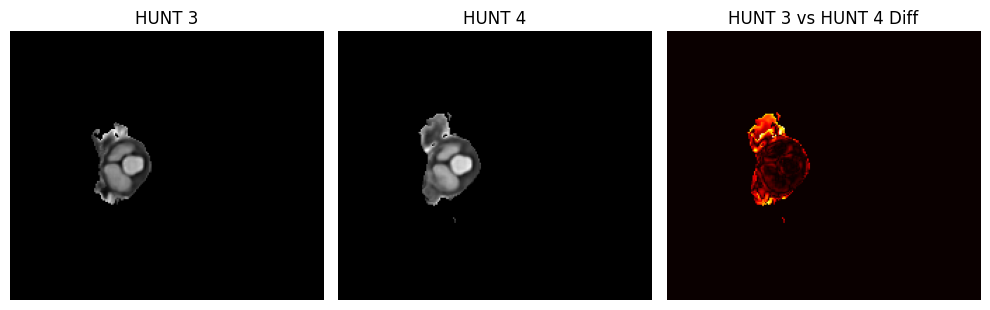

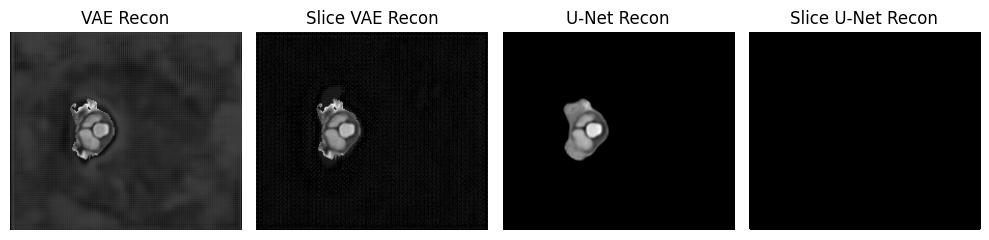

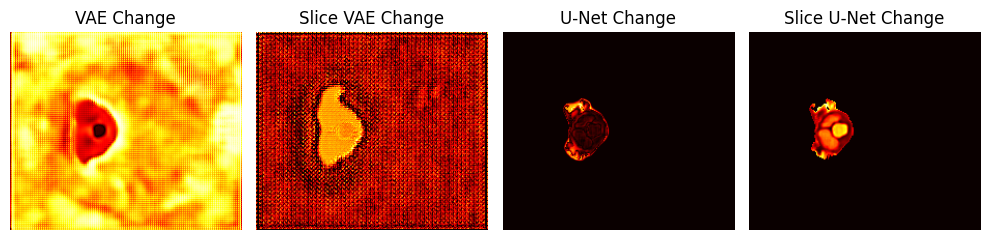

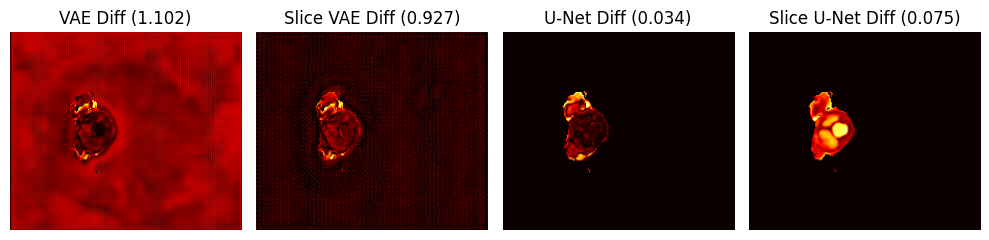

Displaying results for test image 42, slice 55


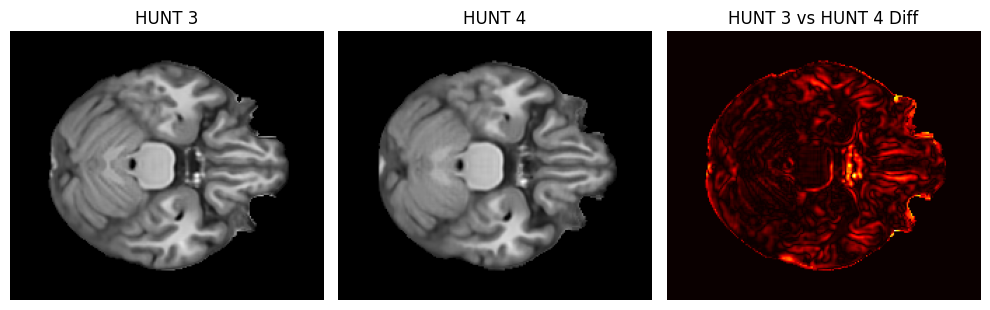

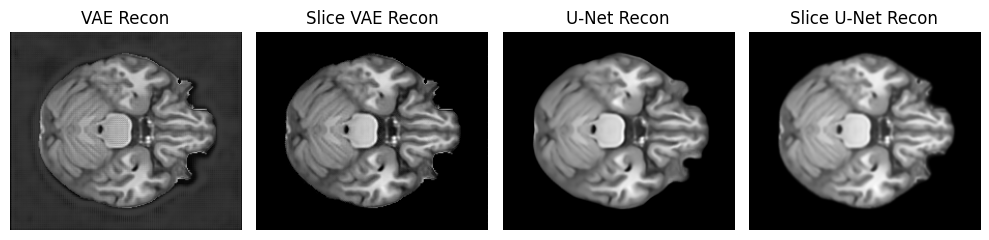

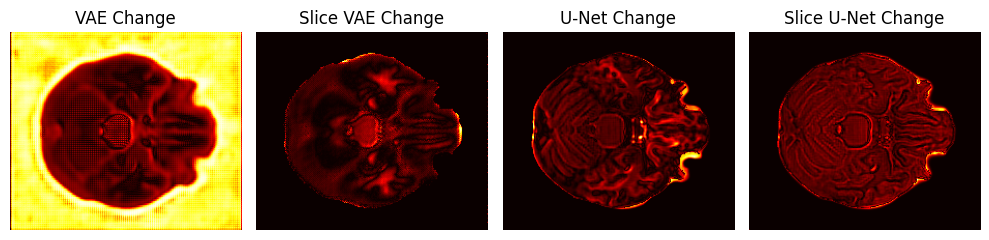

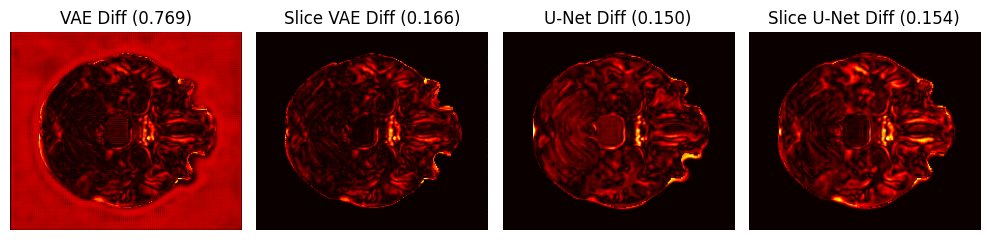

Displaying results for test image 83, slice 96


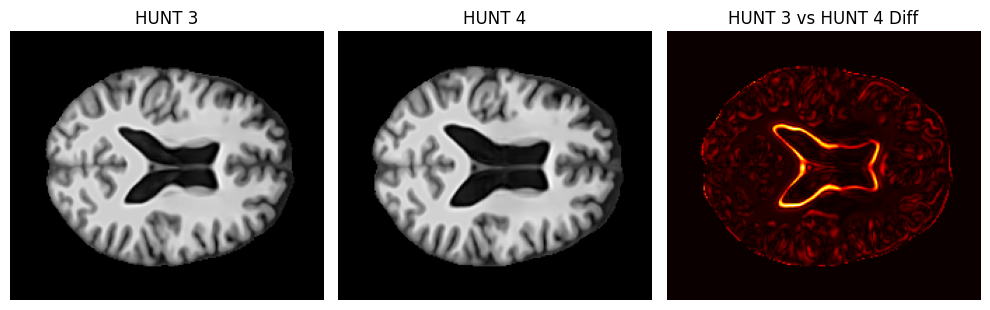

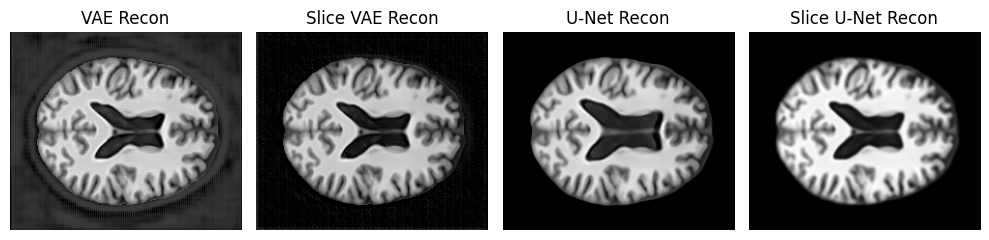

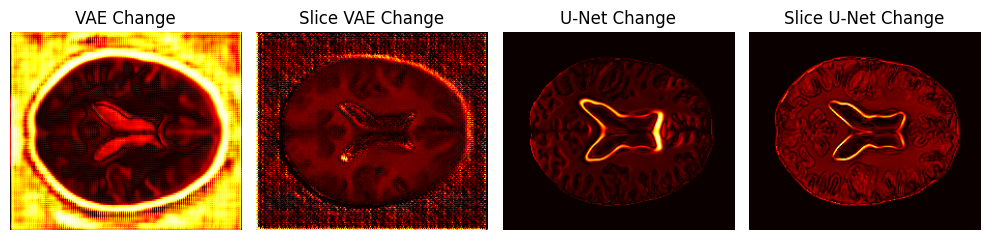

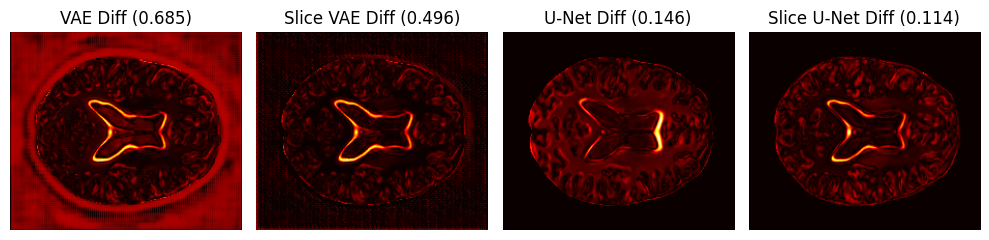

Displaying results for test image 114, slice 136


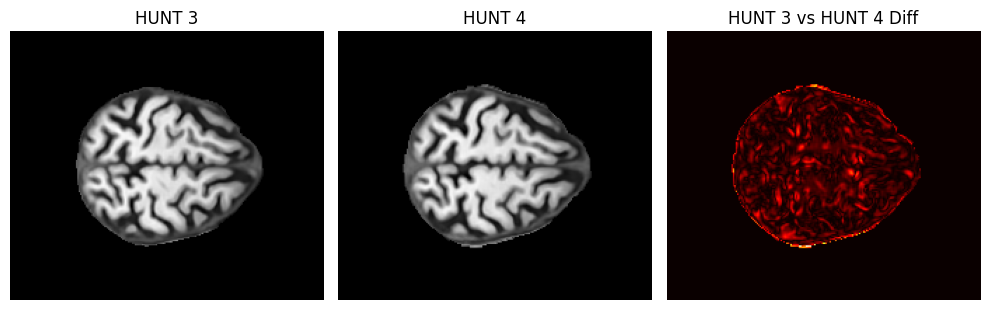

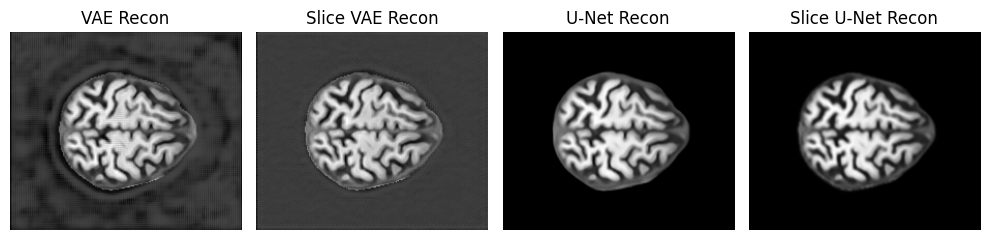

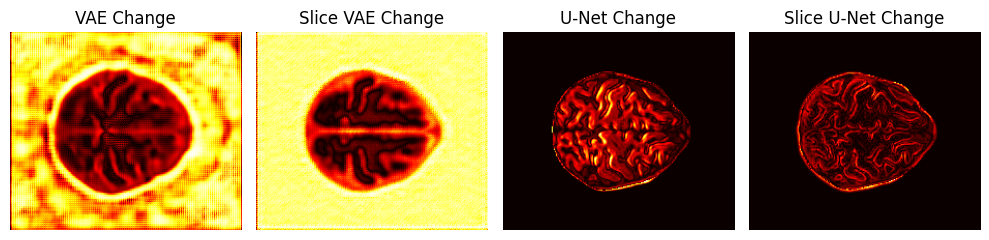

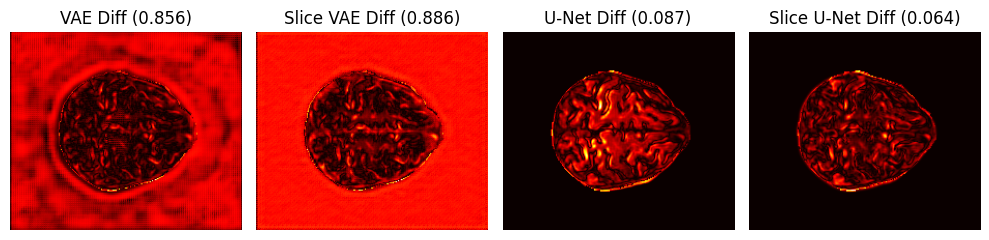

In [ ]:
for i in range(test_images):
    padding = 15
    slice = int(padding + i * ((192 - 2 * padding) / test_images))
    candidate = random.randint(0, len(test_pairs)-1)
    x_num, y_num = data_loader.get_slice(data_path=test_pairs[candidate][0], crop_size=(192, 224), index=slice), data_loader.get_slice(data_path=test_pairs[candidate][1], crop_size=(192, 224), index=slice)
    x = data_loader.to_torch_img(x_num, device)
    y = data_loader.to_torch_img(y_num, device)

    vae_recon_tensor, _, _ = vae(x)
    unet_recon_tensor, _, _ = unet(x)

    slice_vae_recon_tensor, _, _ = slice_vae[slice](x)
    slice_unet_recon_tensor, _, _ = slice_unet[slice](x)
    # Convert Tensor reconstructions to numpy for display
    vae_recon = data_loader.to_numpy_img(vae_recon_tensor)
    unet_recon = data_loader.to_numpy_img(unet_recon_tensor)
    slice_vae_recon = data_loader.to_numpy_img(slice_vae_recon_tensor)
    slice_unet_recon = data_loader.to_numpy_img(slice_unet_recon_tensor)

    # How much the models change from the input
    vae_change = np.abs(vae_recon - x_num)
    unet_change = np.abs(unet_recon - x_num)
    slice_vae_change = np.abs(slice_vae_recon - x_num)
    slice_unet_change = np.abs(slice_unet_recon - x_num)

    # Difference between reconstructions and ground truth
    vae_diff = np.abs(vae_recon - y_num)
    unet_diff = np.abs(unet_recon - y_num)
    slice_vae_diff = np.abs(slice_vae_recon - y_num)
    slice_unet_diff = np.abs(slice_unet_recon - y_num)
    hunt_diff = np.abs(x_num - y_num)

    # Prediction errors (SSIM+L1)
    vae_pred_error = ssim_L1_2d_loss(vae_recon_tensor, y).item()
    unet_pred_error = ssim_L1_2d_loss(unet_recon_tensor, y).item()
    slice_vae_pred_error = ssim_L1_2d_loss(slice_vae_recon_tensor, y).item()
    slice_unet_pred_error = ssim_L1_2d_loss(slice_unet_recon_tensor, y).item()

    print(f"Displaying results for test image {candidate}, slice {slice}")

    # Hunt 3, Hunt 4, and the difference between them
    data_loader.display_slices(
        slices=[x_num, y_num, hunt_diff],
        slice_labels=["HUNT 3", "HUNT 4", "HUNT 3 vs HUNT 4 Diff"],
        slice_colors=["gray", "gray", "hot"]
    )

    # The four models’ outputs
    data_loader.display_slices(
        slices=[vae_recon, slice_vae_recon, unet_recon, slice_unet_recon],
        slice_labels=["VAE Recon", "Slice VAE Recon", "U-Net Recon", "Slice U-Net Recon"],
        slice_colors=["gray", "gray", "gray", "gray"]
    )

    # The four models’ change from HUNT 3
    data_loader.display_slices(
        slices=[vae_change, slice_vae_change, unet_change, slice_unet_change],
        slice_labels=["VAE Change", "Slice VAE Change", "U-Net Change", "Slice U-Net Change"],
        slice_colors=["hot", "hot", "hot", "hot"]
    )

    # The four models’ difference from HUNT 4
    data_loader.display_slices(
        slices=[vae_diff, slice_vae_diff, unet_diff, slice_unet_diff],
        slice_labels=[
            f"VAE Diff ({vae_pred_error:.3f})",
            f"Slice VAE Diff ({slice_vae_pred_error:.3f})",
            f"U-Net Diff ({unet_pred_error:.3f})",
            f"Slice U-Net Diff ({slice_unet_pred_error:.3f})"
        ],
        slice_colors=["hot", "hot", "hot", "hot"]
    )

### My glorious script finding the average error over entire test set

In [ ]:
import torch
import tqdm

# Set models to evaluation mode
vae.eval()
unet.eval()
for m in slice_vae:
    m.eval()
for m in slice_unet:
    m.eval()

# These will average error
avg_vae_error        = 0.0
avg_unet_error       = 0.0
avg_slice_vae_error  = 0.0
avg_slice_unet_error = 0.0

# We go over entire test set
with torch.no_grad():
    for x_path, y_path in tqdm.tqdm(test_pairs):
        # Load each 3D volume ONCE, with cropping
        x_vol = data_loader.load_from_path(x_path, crop_size=(192, 224))
        y_vol = data_loader.load_from_path(y_path, crop_size=(192, 224))

        # Each volume is 193 slices deep (192 with 0-indexation)
        depth = x_vol.shape[2]
        assert depth >= 192, f"Expected at least 192 slices, got {depth}"

        # Go over every slice
        for i in range(192):
            x_slice = x_vol[:, :, i]
            y_slice = y_vol[:, :, i]

            x = data_loader.to_torch_img(x_slice, device)  # (1,1,192,224)
            y = data_loader.to_torch_img(y_slice, device)

            # Global models
            vae_recon, _, _ = vae(x)
            unet_recon, _, _ = unet(x)

            # Slice-wise models
            slice_vae_recon, _, _   = slice_vae[i](x)
            slice_unet_recon, _, _  = slice_unet[i](x)

            vae_error        = ssim_L1_2d_loss(vae_recon,       y).item()
            unet_error       = ssim_L1_2d_loss(unet_recon,      y).item()
            slice_vae_error  = ssim_L1_2d_loss(slice_vae_recon, y).item()
            slice_unet_error = ssim_L1_2d_loss(slice_unet_recon,y).item()
            
            avg_vae_error        += vae_error
            avg_unet_error       += unet_error
            avg_slice_vae_error  += slice_vae_error
            avg_slice_unet_error += slice_unet_error

total_evaluations = len(test_pairs) * 192
avg_vae_error        /= total_evaluations
avg_unet_error       /= total_evaluations
avg_slice_vae_error  /= total_evaluations
avg_slice_unet_error /= total_evaluations

print(f"Average VAE Test Error: {avg_vae_error:.4f}")
print(f"Average U-Net Test Error: {avg_unet_error:.4f}")
print(f"Average Slice-wise VAE Test Error: {avg_slice_vae_error:.4f}")
print(f"Average Slice-wise U-Net Test Error: {avg_slice_unet_error:.4f}")

  0%|          | 0/141 [00:00<?, ?it/s]

100%|██████████| 141/141 [06:55<00:00,  2.94s/it]

Average VAE Test Error: 0.8870
Average U-Net Test Error: 0.0790
Average Slice-wise VAE Test Error: 0.4678
Average Slice-wise U-Net Test Error: 0.0948


#### Test Goofy Ah Saving Script

In [ ]:
# Sleep for 60s to allow Goofy Ah Autosave to trigger
import time
time.sleep(60)

In [ ]:
%autosave 0

Autosave disabled
